<a href="https://colab.research.google.com/github/hirenpatel1404/AI_lab/blob/main/Lesson_6_ml_basic_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hiren Patel
##Lesson 6 ml basic assignment
###California house price prediction

I am working on California house price prediction. First, I look at what I am predicting — the house price — which is a numerical value, so this is a regression problem. The dataset also comes with labelled data (I already know the actual house values), and I use those labels to train the model. Because the model learns from labelled data, this is supervised learning.

In [13]:
#import libreries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import plotly.express as px

#Data Collection and Loading

In [2]:
# Load the California Housing dataset from sklearn
housing = fetch_california_housing()

In [3]:
# Convert the feature data into a pandas DataFrame, with proper column names
df = pd.DataFrame(housing.data, columns=housing.feature_names)

In [4]:
# Add the target column (the house value we want to predict)
df['MedHouseVal'] = housing.target

###Interpretation of Part 2 (Data Collection and Loading):

I loaded the California Housing dataset from sklearn. It doesn't come as a ready-made table, so I converted the feature data into a pandas DataFrame and gave each column its proper name. I then added the target column (MedHouseVal), which is the actual house value I want to predict, so that both the features and the answer are together in one DataFrame.

Go ahead and run it. Once it runs clean with no errors, tell me and we'll move to Part 3 — Quick Check of Data (that's where .head(), .info(), .describe() come in). Want to keep going?

#Part 3 — Quick Check of Data

In [5]:
# Display the first few rows to see the structure of the dataset
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
# Check data types and non-null counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [9]:
# Get statistical summary (mean, min, max, etc.) for each column
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#Part 4 : EDA and Data Preprocessing


- Each row = one block group (a small census area defined by latitude/longitude),
not a single house. This is the key to reading everything correctly.

- The data is not normalized — columns are in their real-world units and on very different scales (income ~3–8, population in the thousands). Linear regression doesn't require scaling, so I left it as-is.


- "Impossible-looking" values are actually fine. Big numbers like AveRooms = 141 or a large population aren't errors — they're real values because the columns are averages/totals across an area, not per house. (Different from the diabetes dataset, where 0s were genuine missing values.)

- Averages stay as decimals. AveRooms = 6.98 is correct and should not be rounded — it's an average across households, not a room count for one house. The "Ave" prefix is the signal.

- Income is in tens of thousands — e.g., MedInc 8.32 ≈ $83,200.
All columns are numerical and continuous — no categorical variables, which fits a regression problem.

In [10]:
# Check for missing/null values in each column
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [18]:
# Interactive scatter plot: Median Income vs House Value
fig = px.scatter(df, x='MedInc', y='MedHouseVal',
                 title='Median Income vs House Value',
                 labels={'MedInc': 'Median Income', 'MedHouseVal': 'Median House Value'})
fig.show()

In [15]:
# Function to automate interactive scatter plots for any feature vs the target
def plot_feature_vs_target(features, target):
    for feature in features:                     # loop through each feature
        fig = px.scatter(df, x=feature, y=target,
                         title=f'{feature} vs {target}')
        fig.show()                               # display this interactive plot

# Use the function
features_to_plot = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
plot_feature_vs_target(features_to_plot, 'MedHouseVal')

In [17]:
# Scatter but zoomed to the normal room range so the pattern is visible
fig = px.scatter(df, x='AveRooms', y='MedHouseVal',
                 title='Average Rooms vs House Value (zoomed)',
                 range_x=[0, 15])                    # only show the sensible room range
fig.show()

In [11]:
# Check correlation between all features and the target
df.corr()['MedHouseVal'].sort_values(ascending=False)

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


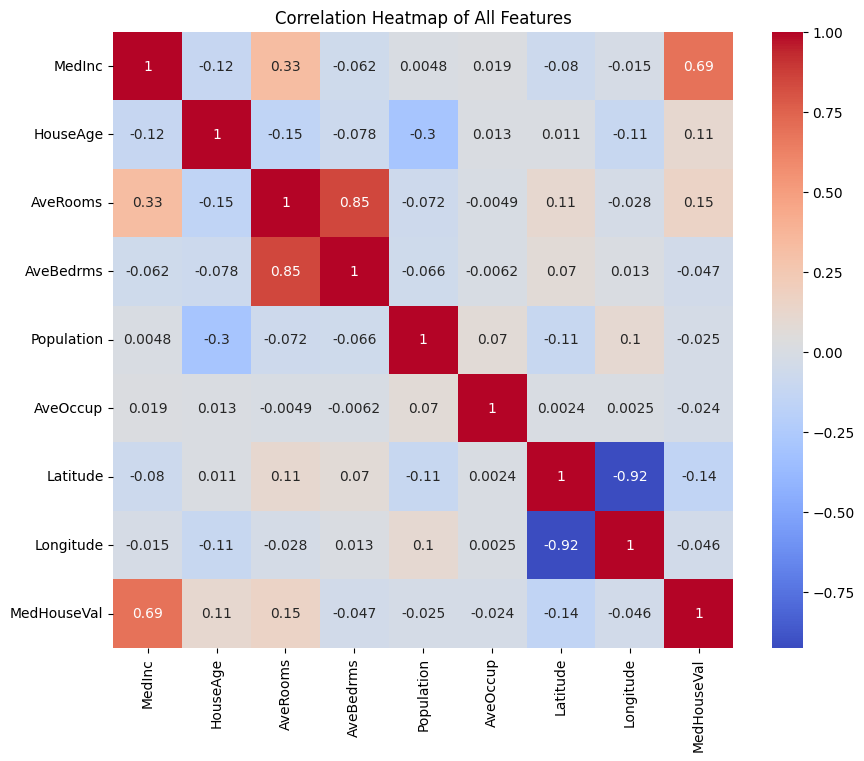

In [19]:
# Correlation heatmap: shows how every feature relates to every other feature
plt.figure(figsize=(10, 8))                          # make the figure big enough to read
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')  # draw the grid with numbers and color
plt.title('Correlation Heatmap of All Features')
plt.show()

###Interpretation of Part 4 (EDA and Data Preprocessing):

I first checked for missing values using .isnull().sum() and confirmed there are no nulls, so no cleaning or imputation was needed. I then explored the data both visually and numerically.

Median Income vs House Value: This plot shows a clear upward trend — as the median income of an area goes up, the house value goes up too. The dots drift from bottom-left to top-right, which tells me income is a strong predictor of house price. I also noticed a flat line of dots at the very top, which is the house value being capped at its maximum ($500,000).

Average Occupancy vs House Value: Most points are clustered at low occupancy values, with a few extreme outliers stretching far to the right. There's no strong upward or downward trend, so average occupancy on its own doesn't tell us much about house value.

House Age vs House Value: The points are spread fairly evenly across all ages, with no strong pattern. This suggests house age has only a weak relationship with house value — older and newer areas can both be expensive or cheap.

Average Rooms vs House Value (zoomed): I zoomed the axis to the normal room range because a few extreme outliers (valid block-group averages, not errors) were stretching the view and hiding the pattern. After zooming, there is a slight upward trend — areas with more rooms per household tend to have somewhat higher house values, but the relationship is weaker and noisier than income.

Correlation with target: Running .corr() on the target confirmed the visuals numerically. Median income had the strongest positive correlation with house value, while features like house age and occupancy had very weak correlations — matching what the scatter plots showed.

Correlation heatmap: The heatmap shows how every feature relates to every other feature at once, using color and numbers. Warm colors mean a strong positive relationship, cool colors mean negative. Besides confirming income as the top predictor, it revealed that some features are strongly related to each other — for example, average rooms and average bedrooms — meaning they carry similar information. The diagonal is all 1.0 because every column is perfectly correlated with itself.

Overall: The main takeaway from EDA is that median income is the most useful predictor of house value, most other features have weaker relationships, and the dataset is clean with no missing values, so it's ready for model training.

#part 5 : ML Model Training:


In [20]:
# Define X (features) and y (target)
# all columns EXCEPT the target
X = df.drop('MedHouseVal', axis=1)
# only the target column
y = df['MedHouseVal']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Choose the regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

LinearRegression()

###Interpretation of Part 5 (ML Model Training):
I separated the data into features (X) — all columns except the target — and the target (y), which is the house value. I then split the data into an 80% training set and a 20% test set, keeping the test set aside so I could evaluate the model fairly on data it had never seen. I chose Linear Regression because this is a regression problem (predicting a continuous number), and trained it on the training data using .fit(), which lets the model learn the relationship between the features and house value.

#Part6 Model Evaluation:


In [27]:
# Calculate R-squared (how much variance the model explains)
r2 = r2_score(y_test, y_pred)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Display the results
print("RMSE:", rmse)
print("R-squared:", r2)

RMSE: 0.7455813830127764
R-squared: 0.5757877060324508


###Interpretation of Part 6 (Model Evaluation):

I evaluated the model on the test set — the 20% of data it never saw during training — so the check would be fair. I used .predict() to generate the model's predicted house values, then compared them against the real values using two metrics.

The RMSE was 0.75. Since house value is measured in hundreds of thousands of dollars, this means the model's predictions are typically off by about $75,000. That's the average size of the error.

The R-squared was 0.58, which means the model explains about 58% of the variation in house prices. In other words, the features (especially income) account for a bit more than half of why house prices differ across areas, while the remaining ~42% is not captured by this simple linear model.

Together, these tell me the model is moderately good — it captures the main trend (income drives price), but it's not highly accurate. A $75,000 average error is fairly large, and explaining 58% of the variation leaves room for improvement. This is expected for a basic Linear Regression model on this dataset; a more advanced model (like Random Forest) or or additional feature engineering (such as creating ratio features or location-based features from latitude and longitude) would likely improve both scores.

#Part 7 Model prediction


In [32]:
# Three new houses (each row = one house)
# Order: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
new_houses = [
    [3, 30, 6, 1, 1500, 3, 34, -118],
    [8, 15, 7, 1, 1200, 2.5, 37, -122],
    [1.5, 45, 4, 1, 3000, 4, 36, -119]
]

In [31]:
# Predict median house values for all three
predicted_values = model.predict(new_houses)

# Print each prediction
for i, value in enumerate(predicted_values):
    print(f"House {i+1} predicted value:", value)

House 1 predicted value: 1.5486633337100812
House 2 predicted value: 4.000677521950607
House 3 predicted value: 0.8557138600659755


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



###Interpretation of Part 7 (Model Prediction):

I used the trained model to predict house values for three completely new areas the model had never seen, keeping the feature values in the same column order used for training. I deliberately varied the inputs — a mid-income area, a high-income coastal area, and a low-income crowded inland area — to test whether the model responds sensibly. The high-income area returned the highest predicted value and the low-income area the lowest, which confirms the model learned the key relationship that income strongly drives house price.

###Challenge
The main challenge was interpreting the data correctly — several values looked impossible at first (very high average rooms, large populations), but understanding that each row represents a block-group average rather than a single house explained them as valid data, not errors.